In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"E:\lebika_training\wineQT.csv")

print(df.head())

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [5]:
X_train = X_train.values
X_test = X_test.values

y_train = y_train.values
y_test = y_test.values

# Add column of 1s for intercept
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (914, 13)
X_test shape: (229, 13)


In [6]:
lambda_0 = 0

# X'X
XTX = np.dot(X_train.T, X_train)

# Identity matrix
I = np.eye(X_train.shape[1])

# Do not regularize intercept
I[0, 0] = 0

# X'X + λI
A = XTX + lambda_0 * I

# Inverse
A_inverse = np.linalg.inv(A)

# X'y
XTy = np.dot(X_train.T, y_train)

# Ridge weights
weights_0 = np.dot(A_inverse, XTy)

# Prediction
y_pred_0 = np.dot(X_test, weights_0)

# MSE
mse_0 = mean_squared_error(y_test, y_pred_0)

print("Lambda =", lambda_0)
print("MSE =", mse_0)
print("Weights =", weights_0)

Lambda = 0
MSE = 0.3824283520895387
Weights = [ 3.64962274e+01  4.48281781e-02 -1.32650965e+00 -3.20227391e-01
  4.64672500e-03 -1.83692523e+00  2.78901313e-03 -2.58694082e-03
 -3.27678330e+01 -2.84072230e-01  9.53929276e-01  2.71613626e-01
 -7.20729446e-05]


In [7]:
lambda_01 = 0.1

XTX = np.dot(X_train.T, X_train)

I = np.eye(X_train.shape[1])
I[0, 0] = 0

A = XTX + lambda_01 * I

A_inverse = np.linalg.inv(A)

XTy = np.dot(X_train.T, y_train)

weights_01 = np.dot(A_inverse, XTy)

y_pred_01 = np.dot(X_test, weights_01)

mse_01 = mean_squared_error(y_test, y_pred_01)

print("Lambda =", lambda_01)
print("MSE =", mse_01)
print("Weights =", weights_01)

Lambda = 0.1
MSE = 0.37979637672142447
Weights = [ 4.49651048e+00  1.54323106e-02 -1.35621828e+00 -3.29546081e-01
 -9.56422067e-03 -1.75649010e+00  3.00473454e-03 -2.63514693e-03
 -1.61571127e-01 -4.35895222e-01  8.88876977e-01  3.03548231e-01
 -6.87049409e-05]


In [8]:
lambda_1 = 1

XTX = np.dot(X_train.T, X_train)

I = np.eye(X_train.shape[1])
I[0, 0] = 0

A = XTX + lambda_1 * I

A_inverse = np.linalg.inv(A)

XTy = np.dot(X_train.T, y_train)

weights_1 = np.dot(A_inverse, XTy)

y_pred_1 = np.dot(X_test, weights_1)

mse_1 = mean_squared_error(y_test, y_pred_1)

print("Lambda =", lambda_1)
print("MSE =", mse_1)
print("Weights =", weights_1)

Lambda = 1
MSE = 0.37564222593111085
Weights = [ 3.96629995e+00  2.05895817e-02 -1.34160249e+00 -3.23761688e-01
 -1.15537763e-02 -1.08531966e+00  3.05863238e-03 -2.59041492e-03
 -1.95523309e-02 -3.54424057e-01  7.85204103e-01  3.10982515e-01
 -6.72337181e-05]


In [9]:
lambda_10 = 10

XTX = np.dot(X_train.T, X_train)

I = np.eye(X_train.shape[1])
I[0, 0] = 0

A = XTX + lambda_10 * I

A_inverse = np.linalg.inv(A)

XTy = np.dot(X_train.T, y_train)

weights_10 = np.dot(A_inverse, XTy)

y_pred_10 = np.dot(X_test, weights_10)

mse_10 = mean_squared_error(y_test, y_pred_10)

print("Lambda =", lambda_10)
print("MSE =", mse_10)
print("Weights =", weights_10)

Lambda = 10
MSE = 0.36391246822867407
Weights = [ 3.07510709e+00  2.22471850e-02 -9.72600074e-01 -4.38189852e-02
 -1.87075695e-02 -2.35771382e-01  4.38626522e-03 -2.95760032e-03
 -3.20332668e-03 -1.79435777e-01  5.22275734e-01  3.23125482e-01
 -7.08368905e-05]


In [10]:
print("Ridge Regression Results")

print("----------------------------")

print("Lambda = 0   | MSE =", mse_0)
print("Lambda = 0.1 | MSE =", mse_01)
print("Lambda = 1   | MSE =", mse_1)
print("Lambda = 10  | MSE =", mse_10)

Ridge Regression Results
----------------------------
Lambda = 0   | MSE = 0.3824283520895387
Lambda = 0.1 | MSE = 0.37979637672142447
Lambda = 1   | MSE = 0.37564222593111085
Lambda = 10  | MSE = 0.36391246822867407


In [11]:
linear_model = LinearRegression()

# Remove manually added intercept column
linear_model.fit(X_train[:, 1:], y_train)

linear_pred = linear_model.predict(X_test[:, 1:])

linear_mse = mean_squared_error(y_test, linear_pred)

print("Linear Regression MSE:", linear_mse)
print("Ridge λ = 0 MSE:", mse_0)

Linear Regression MSE: 0.3824283521291851
Ridge λ = 0 MSE: 0.3824283520895387


In [12]:
scaler = StandardScaler()

# Remove intercept column before scaling
X_train_original = X_train[:, 1:]
X_test_original = X_test[:, 1:]

# Scale training data
X_train_scaled = scaler.fit_transform(X_train_original)

# Scale test data using training statistics
X_test_scaled = scaler.transform(X_test_original)

print("Before scaling:")
print(X_train_original[:3])

print("\nAfter scaling:")
print(X_train_scaled[:3])

Before scaling:
[[8.5000e+00 2.8000e-01 5.6000e-01 1.8000e+00 9.2000e-02 3.5000e+01
  1.0300e+02 9.9690e-01 3.3000e+00 7.5000e-01 1.0500e+01 1.6000e+01]
 [9.9000e+00 3.2000e-01 5.6000e-01 2.0000e+00 7.3000e-02 3.0000e+00
  8.0000e+00 9.9534e-01 3.1500e+00 7.3000e-01 1.1400e+01 1.0760e+03]
 [8.9000e+00 3.1000e-01 3.6000e-01 2.6000e+00 5.6000e-02 1.0000e+01
  3.9000e+01 9.9562e-01 3.4000e+00 6.9000e-01 1.1800e+01 9.0000e+02]]

After scaling:
[[ 0.1426802  -1.40273053  1.5096933  -0.55102394  0.11651554  1.88559834
   1.79122276  0.11355786 -0.09314751  0.56821234  0.05661327 -1.72103768]
 [ 0.96843134 -1.17920341  1.5096933  -0.39776844 -0.28423884 -1.24188154
  -1.18572018 -0.7017669  -1.07474038  0.4477703   0.89445566  0.56050423]
 [ 0.3786091  -1.23508519  0.4833938   0.06199805 -0.64280855 -0.55774532
  -0.21429669 -0.55542656  0.56124774  0.20688622  1.26683005  0.18168217]]


In [13]:
X_train_scaled = np.c_[
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
]

X_test_scaled = np.c_[
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
]

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (914, 13)
Scaled X_test shape: (229, 13)


In [14]:
lambda_scaled = 1

XTX_scaled = np.dot(
    X_train_scaled.T,
    X_train_scaled
)

I_scaled = np.eye(X_train_scaled.shape[1])

# Do not regularize intercept
I_scaled[0, 0] = 0

A_scaled = XTX_scaled + lambda_scaled * I_scaled

A_scaled_inverse = np.linalg.inv(A_scaled)

XTy_scaled = np.dot(
    X_train_scaled.T,
    y_train
)

weights_scaled = np.dot(
    A_scaled_inverse,
    XTy_scaled
)

y_pred_scaled = np.dot(
    X_test_scaled,
    weights_scaled
)

mse_scaled = mean_squared_error(
    y_test,
    y_pred_scaled
)

print("Ridge with scaling")
print("Lambda:", lambda_scaled)
print("MSE:", mse_scaled)
print("Weights:", weights_scaled)

print()

print("Ridge without scaling with lambda as 1")
print("Lambda =", lambda_1)
print("MSE =", mse_1)
print("Weights =", weights_1)

Ridge with scaling
Lambda: 1
MSE: 0.38228078486291023
Weights: [ 5.65645514  0.07594948 -0.2369237  -0.0616572   0.0061472  -0.08713149
  0.02844776 -0.08254925 -0.06306227 -0.04310503  0.15831182  0.2911605
 -0.03338536]

Ridge without scaling with lambda as 1
Lambda = 1
MSE = 0.37564222593111085
Weights = [ 3.96629995e+00  2.05895817e-02 -1.34160249e+00 -3.23761688e-01
 -1.15537763e-02 -1.08531966e+00  3.05863238e-03 -2.59041492e-03
 -1.95523309e-02 -3.54424057e-01  7.85204103e-01  3.10982515e-01
 -6.72337181e-05]


In [15]:
feature_names = ["intercept"] + list(
    df.drop("quality", axis=1).columns
)

print(feature_names)

['intercept', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']


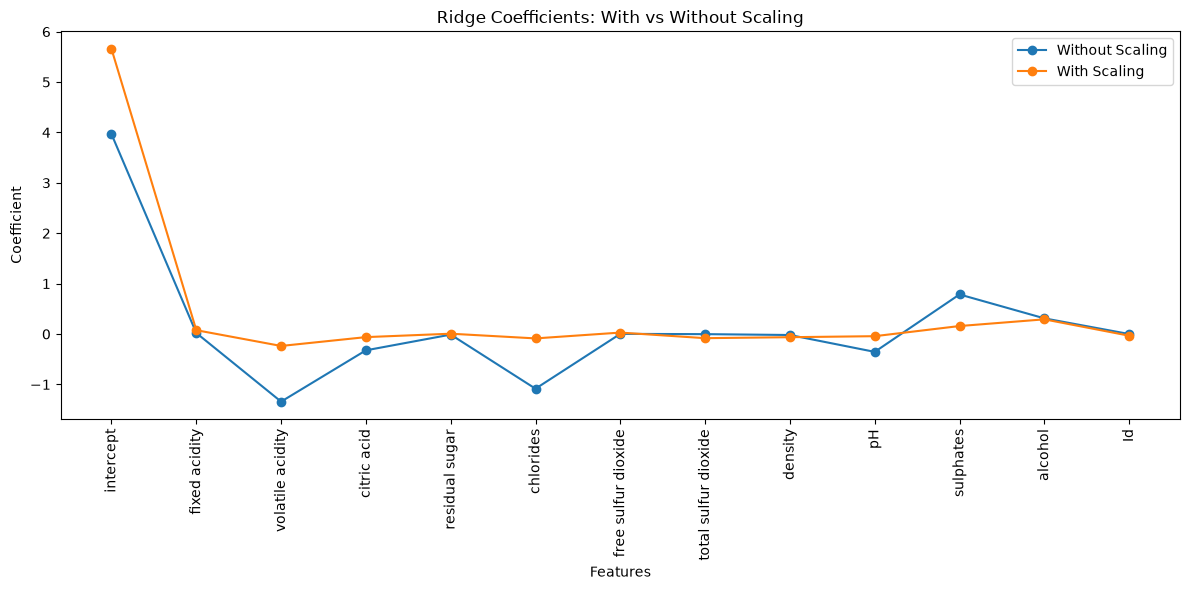

In [16]:
x = np.arange(len(feature_names))

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    weights_1,
    marker="o",
    label="Without Scaling"
)

plt.plot(
    x,
    weights_scaled,
    marker="o",
    label="With Scaling"
)

plt.xticks(
    x,
    feature_names,
    rotation=90
)

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.title(
    "Ridge Coefficients: With vs Without Scaling"
)

plt.legend()

plt.tight_layout()

plt.show()

In [17]:
# Combine X and y so that they can be split together
data = np.c_[X_train, y_train]

# Shuffle the data
np.random.seed(42)
np.random.shuffle(data)

# Create 5 folds
folds = np.array_split(data, 5)

print("Number of folds:", len(folds))

for i in range(5):
    print("Fold", i + 1, "shape:", folds[i].shape)

Number of folds: 5
Fold 1 shape: (183, 14)
Fold 2 shape: (183, 14)
Fold 3 shape: (183, 14)
Fold 4 shape: (183, 14)
Fold 5 shape: (182, 14)


In [18]:
lambdas = [0, 0.001, 0.01, 0.1, 1, 10]

average_validation_errors = []

for lambda_value in lambdas:

    validation_errors = []

    for i in range(5):

        # Current fold = validation data
        validation_data = folds[i]

        # Remaining 4 folds = training data
        training_data = np.concatenate(
            [folds[j] for j in range(5) if j != i]
        )

        # Separate X and y
        X_cv_train = training_data[:, :-1]
        y_cv_train = training_data[:, -1]

        X_cv_val = validation_data[:, :-1]
        y_cv_val = validation_data[:, -1]

        # Calculate X'X
        XTX_cv = np.dot(X_cv_train.T, X_cv_train)

        # Identity matrix
        I_cv = np.eye(X_cv_train.shape[1])

        # Don't penalize intercept
        I_cv[0, 0] = 0

        # Ridge equation
        A_cv = XTX_cv + lambda_value * I_cv

        # Inverse
        A_inverse_cv = np.linalg.inv(A_cv)

        # Calculate X'y
        XTy_cv = np.dot(X_cv_train.T, y_cv_train)

        # Calculate weights
        weights_cv = np.dot(A_inverse_cv, XTy_cv)

        # Predict validation data
        y_cv_pred = np.dot(X_cv_val, weights_cv)

        # Calculate validation MSE
        error = mean_squared_error(y_cv_val, y_cv_pred)

        validation_errors.append(error)

    # Average of 5 validation errors
    average_error = np.mean(validation_errors)

    average_validation_errors.append(average_error)

    print("Lambda:", lambda_value)
    print("Validation MSEs:", validation_errors)
    print("Average Validation MSE:", average_error)
    print("---------------------------")

Lambda: 0
Validation MSEs: [0.509061178645248, 0.4049026125013125, 0.4586264726519716, 0.44734275543032453, 0.36271998949554196]
Average Validation MSE: 0.4365306017448797
---------------------------
Lambda: 0.001
Validation MSEs: [0.5005173458364215, 0.40482577120673346, 0.45292844553982864, 0.4427226571450149, 0.36222333723038264]
Average Validation MSE: 0.4326435113916762
---------------------------
Lambda: 0.01
Validation MSEs: [0.4979576387987326, 0.4049746320389143, 0.4514934127408917, 0.44138070181123223, 0.36227583587043766]
Average Validation MSE: 0.4316164442520417
---------------------------
Lambda: 0.1
Validation MSEs: [0.49842870104120507, 0.40516672185399183, 0.4508458586643913, 0.4396744441111305, 0.36252520525188753]
Average Validation MSE: 0.4313281861845212
---------------------------
Lambda: 1
Validation MSEs: [0.5037690769384531, 0.40489981417907744, 0.45096622821919413, 0.43197904036517637, 0.36587570102929606]
Average Validation MSE: 0.4314979721462394
-----------

In [19]:
print("Cross-Validation Results")
print("-------------------------")

for i in range(len(lambdas)):
    print(
        "Lambda =", lambdas[i],
        "| Average Validation MSE =", average_validation_errors[i]
    )

Cross-Validation Results
-------------------------
Lambda = 0 | Average Validation MSE = 0.4365306017448797
Lambda = 0.001 | Average Validation MSE = 0.4326435113916762
Lambda = 0.01 | Average Validation MSE = 0.4316164442520417
Lambda = 0.1 | Average Validation MSE = 0.4313281861845212
Lambda = 1 | Average Validation MSE = 0.4314979721462394
Lambda = 10 | Average Validation MSE = 0.4397387786087733


In [20]:
best_index = np.argmin(average_validation_errors)

best_lambda = lambdas[best_index]
best_validation_error = average_validation_errors[best_index]

print("Best Lambda:", best_lambda)
print("Best Validation MSE:", best_validation_error)

Best Lambda: 0.1
Best Validation MSE: 0.4313281861845212


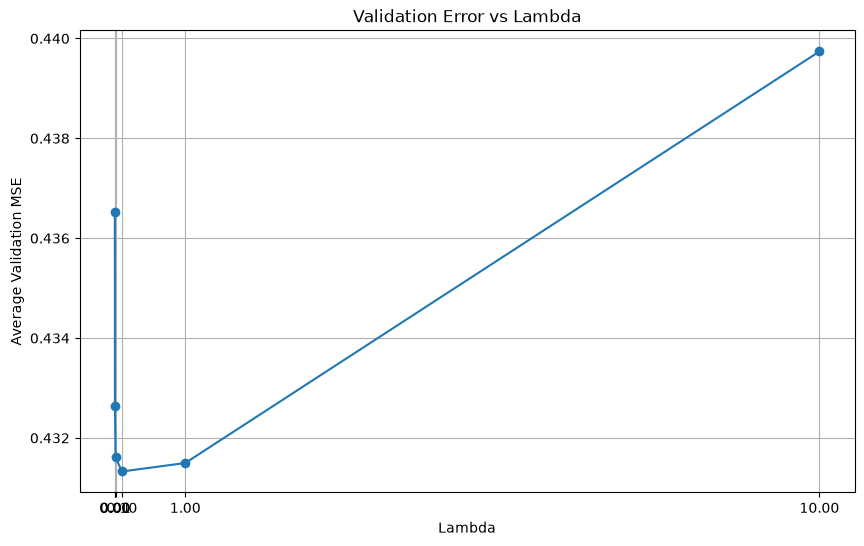

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    lambdas,
    average_validation_errors,
    marker="o"
)

plt.xlabel("Lambda")
plt.ylabel("Average Validation MSE")
plt.title("Validation Error vs Lambda")

plt.xticks(lambdas)

plt.grid(True)
plt.show()

In [22]:
training_errors = []

for lambda_value in lambdas:

    XTX_train = np.dot(X_train.T, X_train)

    I_train = np.eye(X_train.shape[1])

    # Don't penalize intercept
    I_train[0, 0] = 0

    A_train = XTX_train + lambda_value * I_train

    A_inverse_train = np.linalg.inv(A_train)

    XTy_train = np.dot(X_train.T, y_train)

    weights_train = np.dot(A_inverse_train, XTy_train)

    y_train_pred = np.dot(X_train, weights_train)

    train_mse = mean_squared_error(y_train, y_train_pred)

    training_errors.append(train_mse)

    print(
        "Lambda =", lambda_value,
        "| Training MSE =", train_mse
    )

Lambda = 0 | Training MSE = 0.4142324172397366
Lambda = 0.001 | Training MSE = 0.41448968486068444
Lambda = 0.01 | Training MSE = 0.41474551065594906
Lambda = 0.1 | Training MSE = 0.4148175834891329
Lambda = 1 | Training MSE = 0.4159066645149527
Lambda = 10 | Training MSE = 0.4258999965531187


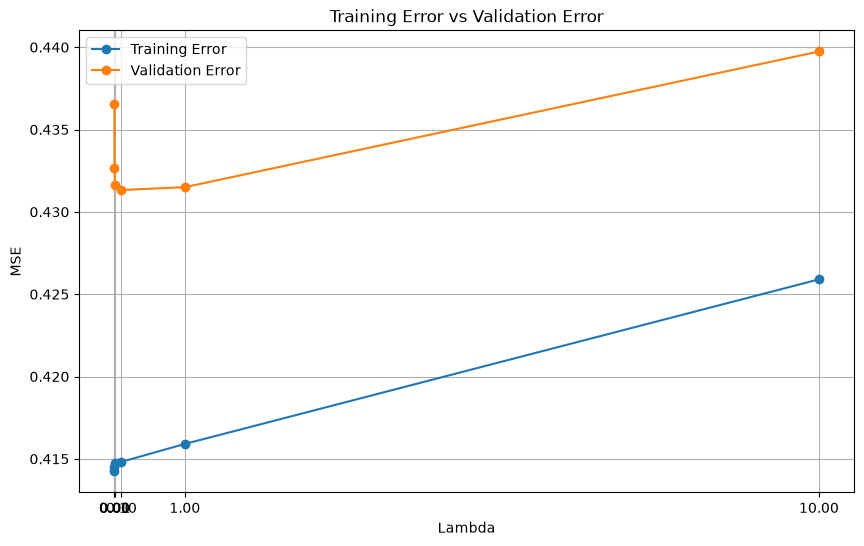

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    lambdas,
    training_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    lambdas,
    average_validation_errors,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("Training Error vs Validation Error")

plt.xticks(lambdas)

plt.legend()
plt.grid(True)

plt.show()

In [24]:
# Linear Regression

linear_model = LinearRegression()

# Remove manually added intercept column
linear_model.fit(X_train[:, 1:], y_train)

linear_pred = linear_model.predict(X_test[:, 1:])

linear_mse = mean_squared_error(y_test, linear_pred)

print("Linear Regression")
print("MSE:", linear_mse)

#best_lambda
# Ridge with optimal lambda

XTX_opt = np.dot(X_train.T, X_train)

I_opt = np.eye(X_train.shape[1])

# Do not penalize intercept
I_opt[0, 0] = 0

A_opt = XTX_opt + best_lambda * I_opt

A_inverse_opt = np.linalg.inv(A_opt)

XTy_opt = np.dot(X_train.T, y_train)

weights_opt = np.dot(A_inverse_opt, XTy_opt)

y_pred_opt = np.dot(X_test, weights_opt)

ridge_opt_mse = mean_squared_error(y_test, y_pred_opt)

print("Ridge with Optimal Lambda")
print("Lambda:", best_lambda)
print("MSE:", ridge_opt_mse)

#C3. Ridge with Very High λ

# Ridge with very high lambda

high_lambda = 1000

XTX_high = np.dot(X_train.T, X_train)

I_high = np.eye(X_train.shape[1])

# Do not penalize intercept
I_high[0, 0] = 0

A_high = XTX_high + high_lambda * I_high

A_inverse_high = np.linalg.inv(A_high)

XTy_high = np.dot(X_train.T, y_train)

weights_high = np.dot(A_inverse_high, XTy_high)

y_pred_high = np.dot(X_test, weights_high)

ridge_high_mse = mean_squared_error(y_test, y_pred_high)

print("Ridge with Very High Lambda")
print("Lambda:", high_lambda)
print("MSE:", ridge_high_mse)

print("Final Model Comparison")
print("----------------------")

print("Linear Regression       MSE:", linear_mse)
print("Ridge Optimal Lambda    MSE:", ridge_opt_mse)
print("Ridge High Lambda=1000  MSE:", ridge_high_mse)

print()

print("Linear Regression Coefficients:")
print(linear_model.coef_)

print("\nRidge Optimal Lambda Coefficients:")
print(weights_opt[1:])

print("\nRidge High Lambda Coefficients:")
print(weights_high[1:])


Linear Regression
MSE: 0.3824283521291851
Ridge with Optimal Lambda
Lambda: 0.1
MSE: 0.37979637672142447
Ridge with Very High Lambda
Lambda: 1000
MSE: 0.4157008801074571
Final Model Comparison
----------------------
Linear Regression       MSE: 0.3824283521291851
Ridge Optimal Lambda    MSE: 0.37979637672142447
Ridge High Lambda=1000  MSE: 0.4157008801074571

Linear Regression Coefficients:
[ 4.48281781e-02 -1.32650965e+00 -3.20227391e-01  4.64672501e-03
 -1.83692523e+00  2.78901313e-03 -2.58694082e-03 -3.27678330e+01
 -2.84072230e-01  9.53929276e-01  2.71613626e-01 -7.20729446e-05]

Ridge Optimal Lambda Coefficients:
[ 1.54323106e-02 -1.35621828e+00 -3.29546081e-01 -9.56422067e-03
 -1.75649010e+00  3.00473454e-03 -2.63514693e-03 -1.61571127e-01
 -4.35895222e-01  8.88876977e-01  3.03548231e-01 -6.87049409e-05]

Ridge High Lambda Coefficients:
[ 3.76791615e-02 -4.40523005e-02  2.14519733e-02 -8.07377013e-03
 -3.08365506e-03  7.86557961e-03 -4.81231344e-03 -1.74030019e-04
 -4.41011466e-0

In [25]:
feature_names = list(
    df.drop("quality", axis=1).columns
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": weights_scaled[1:],
    "Absolute Importance": np.abs(weights_scaled[1:])
})

feature_importance = feature_importance.sort_values(
    "Absolute Importance",
    ascending=False
)

print(feature_importance)

                 Feature  Coefficient  Absolute Importance
10               alcohol     0.291161             0.291161
1       volatile acidity    -0.236924             0.236924
9              sulphates     0.158312             0.158312
4              chlorides    -0.087131             0.087131
6   total sulfur dioxide    -0.082549             0.082549
0          fixed acidity     0.075949             0.075949
7                density    -0.063062             0.063062
2            citric acid    -0.061657             0.061657
8                     pH    -0.043105             0.043105
11                    Id    -0.033385             0.033385
5    free sulfur dioxide     0.028448             0.028448
3         residual sugar     0.006147             0.006147


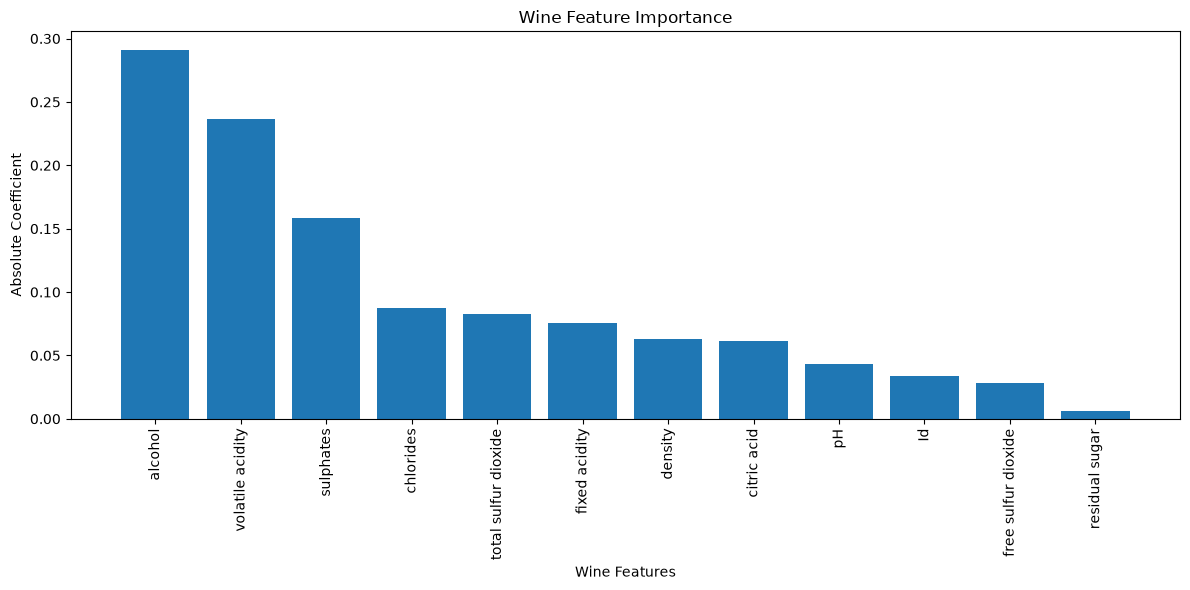

In [26]:
plt.figure(figsize=(12, 6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Absolute Importance"]
)

plt.xlabel("Wine Features")
plt.ylabel("Absolute Coefficient")
plt.title("Wine Feature Importance")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [27]:
comparison = pd.DataFrame({
    "Feature": feature_names,
    "Linear Regression": np.abs(linear_model.coef_),
    "Ridge Optimal": np.abs(weights_opt[1:]),
    "Ridge High Lambda": np.abs(weights_high[1:])
})

print(comparison)

                 Feature  Linear Regression  Ridge Optimal  Ridge High Lambda
0          fixed acidity           0.044828       0.015432           0.037679
1       volatile acidity           1.326510       1.356218           0.044052
2            citric acid           0.320227       0.329546           0.021452
3         residual sugar           0.004647       0.009564           0.008074
4              chlorides           1.836925       1.756490           0.003084
5    free sulfur dioxide           0.002789       0.003005           0.007866
6   total sulfur dioxide           0.002587       0.002635           0.004812
7                density          32.767833       0.161571           0.000174
8                     pH           0.284072       0.435895           0.004410
9              sulphates           0.953929       0.888877           0.026573
10               alcohol           0.271614       0.303548           0.179415
11                    Id           0.000072       0.000069      

In [28]:
business_interpretation = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": weights_scaled[1:]
})

business_interpretation = business_interpretation.sort_values(
    "Coefficient",
    ascending=False
)

print(business_interpretation)

                 Feature  Coefficient
10               alcohol     0.291161
9              sulphates     0.158312
0          fixed acidity     0.075949
5    free sulfur dioxide     0.028448
3         residual sugar     0.006147
11                    Id    -0.033385
8                     pH    -0.043105
2            citric acid    -0.061657
7                density    -0.063062
6   total sulfur dioxide    -0.082549
4              chlorides    -0.087131
1       volatile acidity    -0.236924
